# Memory and Forecasting Analysis

#### Importing Necessary Packages

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

### Defining global variables

In [ ]:
AR_MEAN = 500
REQUIRE_COMPLETE_FORECASTS = True
FORECAST_START_INDEX = 20
EXPECTED_FORECAST_TRIALS = 60

POST_SWITCH_POSITIONS = [0, 1] # Regression (1) requires within-train positions 0 and 1
INCLUDE_PT_MAIN_EFFECT = False # Inclusion/exclusion of participant main effect in regression (2)

### Defining psiturk data importation and plot exportation paths

In [ ]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "db_exports" / "trialdata_expanded.csv"
ASSIGNMENTS_PATH = ROOT / "static" / "data" / "assignments.json"

df = pd.read_csv(DATA_PATH)

with open(ASSIGNMENTS_PATH, "r", encoding="utf-8") as f:
    assignments = json.load(f)

if isinstance(assignments, dict) and "assignments" in assignments:
    assignments = assignments["assignments"]
    
print("Rows in exported data:", len(df))
print("Assignments:", len(assignments))

OUT_DIR = ROOT / "analysis_outputs" / "recent_participant_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUT_DIR / "preliminary_n10_results_tables.pdf"

Rows in exported data: 3861
Assignments: 300


### Formatting table for regression results

In [ ]:
def add_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def format_result_table(df, round_digits=4):
    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(round_digits)
    return out

### Extract assignments and unique ids

In [ ]:
# Participant/session column
if "db_uniqueid" in df.columns:
    participant_col = "db_uniqueid"
elif "uniqueId" in df.columns:
    participant_col = "uniqueId"
else:
    raise ValueError("Could not find participant id column.")

# Assignment column
if "assignment_slot" in df.columns:
    assignment_col = "assignment_slot"
elif "counterbalance" in df.columns:
    assignment_col = "counterbalance"
else:
    raise ValueError("Could not find assignment_slot or counterbalance column.")

participant_col, assignment_col

('db_uniqueid', 'assignment_slot')

### Extract strictly necessary data from assignments with complete data

In [ ]:
def get_assignment_rho(assignment):
    if "rho" in assignment:
        return assignment["rho"]
    if "ar1" in assignment and "rho" in assignment["ar1"]:
        return assignment["ar1"]["rho"]
    raise ValueError("Could not find rho in assignment.")


def ols_slope(y_values, x_values):
    """Slope of an OLS regression of y on x with an intercept."""
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)

    x_centered = x - x.mean()
    denominator = (x_centered ** 2).sum()

    if denominator == 0:
        return np.nan

    return float((x_centered * (y - y.mean())).sum() / denominator)


def get_realized_rho(assignment, forecast_start_index=FORECAST_START_INDEX):
    """Sample AR(1) coefficient of the series this participant actually saw.

    The nominal rho is not the persistence a participant was exposed to. A
    single 80-point draw has a sample rho that scatters (SD ~0.10) and sits
    below nominal by roughly (1 + 3*rho)/T, which is ~0.06 here. Benchmarking
    forecasts against the nominal value therefore charges participants for a
    gap that is a property of the stimulus, not of their behaviour.

    Stimuli from experiment_code_version 3.0.0 onward are conditioned to remove
    this and store the value. Older files (assignments_v1.json, the psiTurk
    pilot) predate the field, so it is recomputed here instead -- which means
    this works against either stimulus file.

    Measured over the forecast rounds, matching the regression below:
    forecasting on round i, the participant has just seen values[i - 1].
    """
    stored = assignment.get("ar1", {}).get("realized_rho_forecast_window")
    if stored is not None:
        return float(stored)

    values = assignment["ar1"]["values"]
    x_values = values[forecast_start_index - 1:len(values) - 1]
    y_values = values[forecast_start_index:]

    return ols_slope(y_values, x_values)


def build_assignment_design(assignments):
    rows = []

    for assignment_index, assignment in enumerate(assignments):
        assignment_slot = assignment.get("assignment_slot", assignment_index)

        values = assignment["ar1"]["values"]
        tasks = assignment["distraction"]["tasks"]
        assigned_rho = get_assignment_rho(assignment)
        realized_rho = get_realized_rho(assignment)

        train_id = -1
        last_task_type = None

        for round_index, task in enumerate(tasks):
            task_type = task["task_type"]

            if task_type != last_task_type:
                train_id += 1
                last_task_type = task_type

            rows.append({
                "assignment_slot": int(assignment_slot),
                "round_index": int(round_index),
                "task_type": task_type,
                "train_id": int(train_id),
                "assigned_rho": float(assigned_rho),

                # Persistence of this particular series, which is what the
                # participant could actually have learned from.
                "realized_rho": float(realized_rho),

                # The AR value revealed on this round.
                "x_next_true": values[round_index],

                # For a forecast on round i, the participant has just seen values[i - 1].
                "x_t": values[round_index - 1] if round_index >= 1 else np.nan,
                "x_t_minus_1": values[round_index - 2] if round_index >= 2 else np.nan,
                "x_t_minus_2": values[round_index - 3] if round_index >= 3 else np.nan,
            })

    design = pd.DataFrame(rows)

    # Train boundaries and train means.
    train_info = (
        design
        .groupby(["assignment_slot", "train_id", "task_type"], as_index=False)
        .agg(
            x_train_mean=("x_next_true", "mean"),
            train_start_round=("round_index", "min"),
            train_end_round=("round_index", "max"),
            train_length=("round_index", "count"),
        )
    )

    # Previous same-task train mean.
    train_info = train_info.sort_values(
        ["assignment_slot", "task_type", "train_start_round"]
    )

    train_info["x_match"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["x_train_mean"]
        .shift(1)
    )

    train_info["matched_train_id"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["train_id"]
        .shift(1)
    )

    design = design.merge(
        train_info[
            [
                "assignment_slot",
                "train_id",
                "x_train_mean",
                "x_match",
                "matched_train_id",
                "train_start_round",
                "train_end_round",
                "train_length",
            ]
        ],
        on=["assignment_slot", "train_id"],
        how="left"
    )

    # p_t: within-train position, 0 at the switch.
    design["p_t"] = design["round_index"] - design["train_start_round"]

    return design


assignment_design = build_assignment_design(assignments)

# How far the stimuli actually sit from their nominal persistence. Near zero
# for conditioned stimuli; ~-0.06 with wide scatter for the older files.
_rho_check = (
    assignment_design
    .groupby("assigned_rho")["realized_rho"]
    .agg(["mean", "std", "min", "max"])
)
print("Realized rho by nominal rho:")
print(_rho_check.round(4))

assignment_design.head()

### Clean up data and create dataframe for analysis

In [ ]:
forecast_rows = df[df["phase"] == "forecast"].copy()

forecast_rows["round_index"] = pd.to_numeric(
    forecast_rows["round_index"], errors="coerce"
)

forecast_rows["forecast_value"] = pd.to_numeric(
    forecast_rows["forecast_value"], errors="coerce"
)

forecast_rows[assignment_col] = pd.to_numeric(
    forecast_rows[assignment_col], errors="coerce"
)

forecast_rows = forecast_rows.dropna(
    subset=[participant_col, assignment_col, "round_index", "forecast_value"]
).copy()

forecast_rows["assignment_slot"] = forecast_rows[assignment_col].astype(int)
forecast_rows["round_index"] = forecast_rows["round_index"].astype(int)

forecast_small = forecast_rows[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "forecast_value",
    ]
].copy()

# Avoid duplicate forecast rows if repeated debug runs created duplicates.
forecast_small = (
    forecast_small
    .sort_values([participant_col, "assignment_slot", "round_index"])
    .drop_duplicates(
        subset=[participant_col, "assignment_slot", "round_index"],
        keep="last"
    )
)

analysis_df = forecast_small.merge(
    assignment_design,
    on=["assignment_slot", "round_index"],
    how="left"
)

analysis_df["rho_group"] = analysis_df["assigned_rho"].round(1)

analysis_df[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "rho_group",
        "task_type",
        "train_id",
        "p_t",
        "forecast_value",
        "x_t",
        "x_t_minus_1",
        "x_t_minus_2",
        "x_match",
    ]
].head(5)

,db_uniqueid,assignment_slot,round_index,rho_group,task_type,train_id,p_t,forecast_value,x_t,x_t_minus_1,x_t_minus_2,x_match
0,debug2xcPZ:debugwyuV6,169,20,0.6,size,4,0,502.0,518.0,506.0,473.0,501.75
1,debug2xcPZ:debugwyuV6,169,21,0.6,size,4,1,498.0,523.0,518.0,506.0,501.75
2,debug2xcPZ:debugwyuV6,169,22,0.6,size,4,2,497.0,513.0,523.0,518.0,501.75
3,debug2xcPZ:debugwyuV6,169,23,0.6,size,4,3,500.0,534.0,513.0,523.0,501.75
4,debug2xcPZ:debugwyuV6,169,24,0.6,size,4,4,498.0,485.0,534.0,513.0,501.75


### Calculate persistence implied by participant forecasts

In [ ]:
persistence_df = analysis_df.dropna(
    subset=[
        participant_col,
        "rho_group",
        "forecast_value",
        "x_t",
    ]
).copy()

persistence_df["forecast_c"] = persistence_df["forecast_value"] - AR_MEAN
persistence_df["x_t_c"] = persistence_df["x_t"] - AR_MEAN

participant_persistence_rows = []

for participant_id, g in persistence_df.groupby(participant_col):
    g = g.copy()

    if REQUIRE_COMPLETE_FORECASTS and len(g) != EXPECTED_FORECAST_TRIALS:
        continue

    rho_values = g["rho_group"].dropna().unique()
    if len(rho_values) != 1:
        continue

    rho_value = rho_values[0]

    realized_rho_values = g["realized_rho"].dropna().unique()
    if len(realized_rho_values) != 1:
        continue

    realized_rho = realized_rho_values[0]

    if len(g) < 5:
        continue

    if g["x_t_c"].nunique() < 2:
        continue

    try:
        res = smf.ols(
            "forecast_c ~ x_t_c",
            data=g
        ).fit()

        implied_rho = res.params.get("x_t_c", np.nan)

        participant_persistence_rows.append({
            "participant": participant_id,
            "assigned_rho": rho_value,
            "realized_rho": realized_rho,
            "implied_rho": implied_rho,

            # Overreaction is implied persistence in excess of the persistence
            # actually present in the series the participant saw. Benchmarking
            # against the nominal rho instead would score a participant who
            # learned their own series perfectly as under-reacting, purely
            # because of small-sample bias in the stimulus.
            "rho_excess": implied_rho - realized_rho,

            # The previous nominal-rho benchmark, kept so the two can be
            # compared and reported side by side.
            "rho_excess_vs_nominal": implied_rho - rho_value,

            "n_obs": int(res.nobs),
            "r_squared": res.rsquared,
        })

    except Exception as e:
        print(f"Could not estimate persistence for participant {participant_id}: {e}")

participant_persistence = pd.DataFrame(participant_persistence_rows)

participant_persistence.head()

### Test for baseline overreaction

In [ ]:
persistence_test_rows = []

for rho_value, g in participant_persistence.groupby("assigned_rho"):
    excess = g["rho_excess"].dropna()
    excess_vs_nominal = g["rho_excess_vs_nominal"].dropna()

    test = stats.ttest_1samp(
        excess,
        popmean=0,
        alternative="greater"
    )

    # Same test against the nominal rho, so the effect of the benchmark is
    # visible rather than buried in a choice made upstream.
    test_vs_nominal = stats.ttest_1samp(
        excess_vs_nominal,
        popmean=0,
        alternative="greater"
    )

    persistence_test_rows.append({
        "assigned_rho": rho_value,
        "n_participants": len(excess),
        "mean_realized_rho": g["realized_rho"].mean(),
        "mean_implied_rho": g["implied_rho"].mean(),
        "median_implied_rho": g["implied_rho"].median(),
        "mean_rho_excess": excess.mean(),
        "median_rho_excess": excess.median(),
        "sd_rho_excess": excess.std(ddof=1),
        "t_stat": test.statistic,
        "p_value_implied_rho_greater_than_true_rho": test.pvalue,

        "mean_rho_excess_vs_nominal": excess_vs_nominal.mean(),
        "t_stat_vs_nominal": test_vs_nominal.statistic,
        "p_value_vs_nominal": test_vs_nominal.pvalue,
    })

persistence_tests = pd.DataFrame(persistence_test_rows)

persistence_tests

### Prep data for regressions

In [ ]:
def prepare_regression_df(analysis_df):
    out = analysis_df.dropna(
        subset=[
            participant_col,
            "rho_group",
            "forecast_value",
            "x_t",
            "x_t_minus_1",
            "x_match",
            "p_t",
        ]
    ).copy()

    out["forecast_c"] = out["forecast_value"] - AR_MEAN
    out["x_t_c"] = out["x_t"] - AR_MEAN
    out["x_t_minus_1_c"] = out["x_t_minus_1"] - AR_MEAN
    out["x_t_minus_2_c"] = out["x_t_minus_2"] - AR_MEAN
    out["x_match_c"] = out["x_match"] - AR_MEAN

    out["p_t"] = pd.to_numeric(out["p_t"], errors="coerce")
    out["p_t_x_match_c"] = out["p_t"] * out["x_match_c"]

    return out


reg_df = prepare_regression_df(analysis_df)

reg_df[
    [
        participant_col,
        "rho_group",
        "round_index",
        "task_type",
        "train_id",
        "p_t",
        "forecast_c",
        "x_t_c",
        "x_t_minus_1_c",
        "x_t_minus_2_c",
        "x_match_c",
        "p_t_x_match_c",
    ]
].head()

,db_uniqueid,rho_group,round_index,task_type,train_id,p_t,forecast_c,x_t_c,x_t_minus_1_c,x_t_minus_2_c,x_match_c,p_t_x_match_c
0,debug2xcPZ:debugwyuV6,0.6,20,size,4,0,2.0,18.0,6.0,-27.0,1.75,0.00
1,debug2xcPZ:debugwyuV6,0.6,21,size,4,1,-2.0,23.0,18.0,6.0,1.75,1.75
2,debug2xcPZ:debugwyuV6,0.6,22,size,4,2,-3.0,13.0,23.0,18.0,1.75,3.50
3,debug2xcPZ:debugwyuV6,0.6,23,size,4,3,0.0,34.0,13.0,23.0,1.75,5.25
4,debug2xcPZ:debugwyuV6,0.6,24,size,4,4,-2.0,-15.0,34.0,13.0,1.75,7.00


### Post-switch forecast bias regression

In [ ]:
def participant_level_simple_gamma_postswitch(reg_df, lag_spec, post_switch_positions=[0, 1]):
    """
    Estimate participant-level gamma using only post-switch trials.

    post_switch_positions = [0, 1] means:
        p_t = 0: first trial after the task switch
        p_t = 1: second trial after the task switch

    lag_spec = 2:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c

    lag_spec = 3:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c
    """

    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c"

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c"

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    rows = []

    # Keep only post-switch positions
    temp = reg_df.copy()
    temp = temp[temp["p_t"].isin(post_switch_positions)].copy()
    temp = temp.dropna(subset=needed).copy()

    for participant_id, g in temp.groupby(participant_col):
        g = g.copy()

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        # Fewer observations now because we only use p_t = 0 and p_t = 1
        if len(g) < 8:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "post_switch_positions": str(post_switch_positions),
                "gamma": res.params.get("x_match_c", np.nan),
                "gamma_se": res.bse.get("x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate post-switch gamma for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [ ]:
simple_gamma_postswitch_2 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch = pd.concat(
    [simple_gamma_postswitch_2, simple_gamma_postswitch_3],
    ignore_index=True
)

simple_gammas_postswitch.head()


simple_gamma_postswitch_test_rows = []

for (rho_value, lag_spec), g in simple_gammas_postswitch.groupby(["assigned_rho", "lag_spec"]):
    gamma_values = g["gamma"].dropna()

    test = stats.ttest_1samp(
        gamma_values,
        popmean=0,
        alternative="greater"
    )

    simple_gamma_postswitch_test_rows.append({
        "assigned_rho": rho_value,
        "lag_spec": lag_spec,
        "post_switch_positions": str(POST_SWITCH_POSITIONS),
        "n_participants": len(gamma_values),
        "mean_gamma": gamma_values.mean(),
        "median_gamma": gamma_values.median(),
        "sd_gamma": gamma_values.std(ddof=1),
        "t_stat": test.statistic,
        "p_value_gamma_greater_than_0": test.pvalue,
    })

simple_gamma_postswitch_tests = pd.DataFrame(simple_gamma_postswitch_test_rows)

In [ ]:
gamma_condition_postswitch_test_rows = []

for lag_spec, g in simple_gammas_postswitch.groupby("lag_spec"):
    gamma_06 = g[g["assigned_rho"].round(1) == 0.6]["gamma"].dropna()
    gamma_07 = g[g["assigned_rho"].round(1) == 0.7]["gamma"].dropna()

    test = stats.ttest_ind(
        gamma_07,
        gamma_06,
        equal_var=False,
        alternative="greater"
    )

    gamma_condition_postswitch_test_rows.append({
        "lag_spec": lag_spec,
        "post_switch_positions": str(POST_SWITCH_POSITIONS),
        "n_rho_06": len(gamma_06),
        "n_rho_07": len(gamma_07),
        "mean_gamma_rho_06": gamma_06.mean(),
        "mean_gamma_rho_07": gamma_07.mean(),
        "difference_07_minus_06": gamma_07.mean() - gamma_06.mean(),
        "sd_gamma_rho_06": gamma_06.std(ddof=1),
        "sd_gamma_rho_07": gamma_07.std(ddof=1),
        "welch_t_stat": test.statistic,
        "p_value_rho_07_greater_than_rho_06": test.pvalue,
    })

gamma_condition_postswitch_tests = pd.DataFrame(gamma_condition_postswitch_test_rows)

In [ ]:
print("Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1")
display(simple_gamma_postswitch_tests)

print("Post-switch gamma comparison: rho 0.7 > rho 0.6")
display(gamma_condition_postswitch_tests)

Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1


,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,sd_gamma,t_stat,p_value_gamma_greater_than_0
0,0.6,2,"[0, 1]",6,-0.198458,-0.166878,0.189914,-2.559688,0.974667
1,0.6,3,"[0, 1]",6,-0.201423,-0.167160,0.190251,-2.593329,0.975680
2,0.7,2,"[0, 1]",4,0.133748,0.126192,0.247497,1.080800,0.179461
3,0.7,3,"[0, 1]",4,0.146758,0.128197,0.227554,1.289871,0.143766


Post-switch gamma comparison: rho 0.7 > rho 0.6


,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,sd_gamma_rho_06,sd_gamma_rho_07,welch_t_stat,p_value_rho_07_greater_than_rho_06
0,2,"[0, 1]",6,4,-0.198458,0.133748,0.332205,0.189914,0.247497,2.274902,0.034388
1,3,"[0, 1]",6,4,-0.201423,0.146758,0.348181,0.190251,0.227554,2.527447,0.023424


### Reinstatement decay across train position regression

In [ ]:
def participant_level_interaction_gammas(reg_df, lag_spec, include_pt_main_effect=False):
    """
    lag_spec = 2:
        controls x_t and x_t_minus_1

    lag_spec = 3:
        controls x_t, x_t_minus_1, and x_t_minus_2

    include_pt_main_effect=False matches written equation.
    include_pt_main_effect=True controls for average within-train drift (just in case).
    """
    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
        ]

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
        ]

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    if include_pt_main_effect:
        predictors = predictors + ["p_t"]

    predictors = predictors + ["x_match_c", "p_t_x_match_c"]

    formula = "forecast_c ~ " + " + ".join(predictors)

    rows = []

    for participant_id, g in reg_df.dropna(subset=needed).groupby(participant_col):
        g = g.copy()

        if REQUIRE_COMPLETE_FORECASTS and len(g) < 40:
            continue

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        if len(g) < len(predictors) + 3:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        if g["p_t_x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "include_pt_main_effect": include_pt_main_effect,
                "gamma_0": res.params.get("x_match_c", np.nan),
                "gamma_1": res.params.get("p_t_x_match_c", np.nan),
                "gamma_0_se": res.bse.get("x_match_c", np.nan),
                "gamma_1_se": res.bse.get("p_t_x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate interaction gammas for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [ ]:
interaction_gamma_2 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas = pd.concat(
    [interaction_gamma_2, interaction_gamma_3],
    ignore_index=True
)

interaction_gammas.head()

,participant,assigned_rho,lag_spec,include_pt_main_effect,gamma_0,gamma_1,gamma_0_se,gamma_1_se,n_obs,r_squared,formula
0,debug2xcPZ:debugwyuV6,0.6,2,False,-0.406951,-0.068567,0.328716,0.132322,60,0.466637,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
1,debug8f1yz:debugmLLaG,0.7,2,False,0.238957,-0.038104,0.254502,0.112531,60,0.379506,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
2,debugOGYa7:debuguT5lw,0.6,2,False,0.008413,-0.017246,0.136839,0.049656,60,0.786936,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
3,debugSaEAR:debugeOixl,0.6,2,False,-0.153592,-0.019729,0.300932,0.112993,60,0.185118,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
4,debugTNy2j:debught3ku,0.7,2,False,0.125744,-0.053755,0.101361,0.037169,60,0.889486,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...


In [ ]:
interaction_gamma_test_rows = []

for (rho_value, lag_spec), g in interaction_gammas.groupby(["assigned_rho", "lag_spec"]):
    gamma_0_values = g["gamma_0"].dropna()
    gamma_1_values = g["gamma_1"].dropna()

    gamma_0_test = stats.ttest_1samp(
        gamma_0_values,
        popmean=0,
        alternative="greater"
    )

    gamma_1_test = stats.ttest_1samp(
        gamma_1_values,
        popmean=0,
        alternative="less"
    )

    interaction_gamma_test_rows.append({
        "assigned_rho": rho_value,
        "lag_spec": lag_spec,

        "n_participants_gamma_0": len(gamma_0_values),
        "mean_gamma_0": gamma_0_values.mean(),
        "median_gamma_0": gamma_0_values.median(),
        "sd_gamma_0": gamma_0_values.std(ddof=1),
        "t_gamma_0": gamma_0_test.statistic,
        "p_value_gamma_0_greater_than_0": gamma_0_test.pvalue,

        "n_participants_gamma_1": len(gamma_1_values),
        "mean_gamma_1": gamma_1_values.mean(),
        "median_gamma_1": gamma_1_values.median(),
        "sd_gamma_1": gamma_1_values.std(ddof=1),
        "t_gamma_1": gamma_1_test.statistic,
        "p_value_gamma_1_less_than_0": gamma_1_test.pvalue,
    })

interaction_gamma_tests = pd.DataFrame(interaction_gamma_test_rows)

interaction_gamma_tests

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,median_gamma_0,sd_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,n_participants_gamma_1,mean_gamma_1,median_gamma_1,sd_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0
0,0.6,2,6,-0.190993,-0.135167,0.162549,-2.878116,0.982668,6,0.023141,0.001110,0.075123,0.754555,0.757741
1,0.6,3,6,-0.198903,-0.146530,0.163809,-2.974260,0.984498,6,0.025284,-0.002238,0.070576,0.877538,0.789823
2,0.7,2,4,0.118130,0.157668,0.141097,1.674459,0.096317,4,-0.016293,-0.012723,0.034817,-0.935943,0.209173
3,0.7,3,4,0.119350,0.149379,0.129935,1.837074,0.081757,4,-0.015049,-0.014789,0.035936,-0.837559,0.231877


### Build plots for N most recent participants

In [ ]:
NUMBER_OF_PLOTS = 10

In [ ]:
def estimate_slope_from_centered_ols(g, y_col, x_col="x_t", mean_value=500):
    """
    Estimate slope from:
        y - mean = alpha + slope * (x - mean) + error
    """
    temp = g[[x_col, y_col]].copy()
    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")
    temp = temp.dropna()

    if len(temp) < 5:
        return np.nan

    temp["x_c"] = temp[x_col] - mean_value
    temp["y_c"] = temp[y_col] - mean_value

    if temp["x_c"].nunique() < 2:
        return np.nan

    try:
        res = smf.ols("y_c ~ x_c", data=temp).fit()
        return res.params["x_c"]
    except Exception:
        return np.nan


def get_final_scores(df, participant_col):
    """
    Pull final cumulative score from forecast feedback rows.
    """
    score_rows = df[df["phase"] == "forecast_feedback_recitation"].copy()

    if "cumulative_score" not in score_rows.columns:
        return pd.DataFrame({
            participant_col: [],
            "final_score": []
        })

    score_rows["cumulative_score"] = pd.to_numeric(
        score_rows["cumulative_score"], errors="coerce"
    )

    final_scores = (
        score_rows
        .dropna(subset=[participant_col, "cumulative_score"])
        .groupby(participant_col, as_index=False)
        .agg(final_score=("cumulative_score", "max"))
    )

    return final_scores


def get_recent_participants(df, participant_col, n=5):
    """
    Uses row order in the exported CSV as the notion of recency.
    The participants whose rows appear latest in df are treated as most recent.
    """
    temp = df.reset_index().rename(columns={"index": "_row_order"})

    recent = (
        temp
        .dropna(subset=[participant_col])
        .groupby(participant_col, as_index=False)
        .agg(last_row=("_row_order", "max"))
        .sort_values("last_row", ascending=False)
        .head(n)
    )

    return recent[participant_col].tolist()


def build_recent_plot_df_with_passive_values(analysis_df, assignment_design, df, participant_col):
    """
    Build plotting dataframe with:
      - all true AR(1) values, including passive observation phase
      - participant forecasts merged only where forecasts exist
    """

    # Participant -> assignment mapping, from observed forecast rows
    participant_assignments = (
        analysis_df
        .dropna(subset=[participant_col, "assignment_slot"])
        [[participant_col, "assignment_slot"]]
        .drop_duplicates()
        .copy()
    )

    participant_assignments["assignment_slot"] = pd.to_numeric(
        participant_assignments["assignment_slot"], errors="coerce"
    ).astype(int)

    # Full true-value sequence for each assignment
    true_values = assignment_design[
        [
            "assignment_slot",
            "round_index",
            "x_next_true",
            "x_t",
            "assigned_rho",
            "task_type",
            "train_id",
            "p_t",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "x_next_true", "x_t", "assigned_rho", "p_t"]:
        true_values[col] = pd.to_numeric(true_values[col], errors="coerce")

    true_values["assignment_slot"] = true_values["assignment_slot"].astype(int)
    true_values["round_index"] = true_values["round_index"].astype(int)

    # Expand full true-value sequence to each participant's assignment
    full_plot_df = participant_assignments.merge(
        true_values,
        on="assignment_slot",
        how="left"
    )

    # Forecasts exist only for forecast trials
    forecasts = analysis_df[
        [
            participant_col,
            "assignment_slot",
            "round_index",
            "forecast_value",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "forecast_value"]:
        forecasts[col] = pd.to_numeric(forecasts[col], errors="coerce")

    forecasts = forecasts.dropna(
        subset=[participant_col, "assignment_slot", "round_index", "forecast_value"]
    ).copy()

    forecasts["assignment_slot"] = forecasts["assignment_slot"].astype(int)
    forecasts["round_index"] = forecasts["round_index"].astype(int)

    forecasts = (
        forecasts
        .sort_values([participant_col, "assignment_slot", "round_index"])
        .drop_duplicates(
            subset=[participant_col, "assignment_slot", "round_index"],
            keep="last"
        )
    )

    # Merge forecasts onto the full true-value sequence
    full_plot_df = full_plot_df.merge(
        forecasts,
        on=[participant_col, "assignment_slot", "round_index"],
        how="left"
    )

    # Add final scores
    final_scores = get_final_scores(df, participant_col)

    full_plot_df = full_plot_df.merge(
        final_scores,
        on=participant_col,
        how="left"
    )

    return full_plot_df

recent_plot_df = build_recent_plot_df_with_passive_values(
    analysis_df=analysis_df,
    assignment_design=assignment_design,
    df=df,
    participant_col=participant_col
)

recent_participants = get_recent_participants(
    df=df,
    participant_col=participant_col,
    n=NUMBER_OF_PLOTS
)

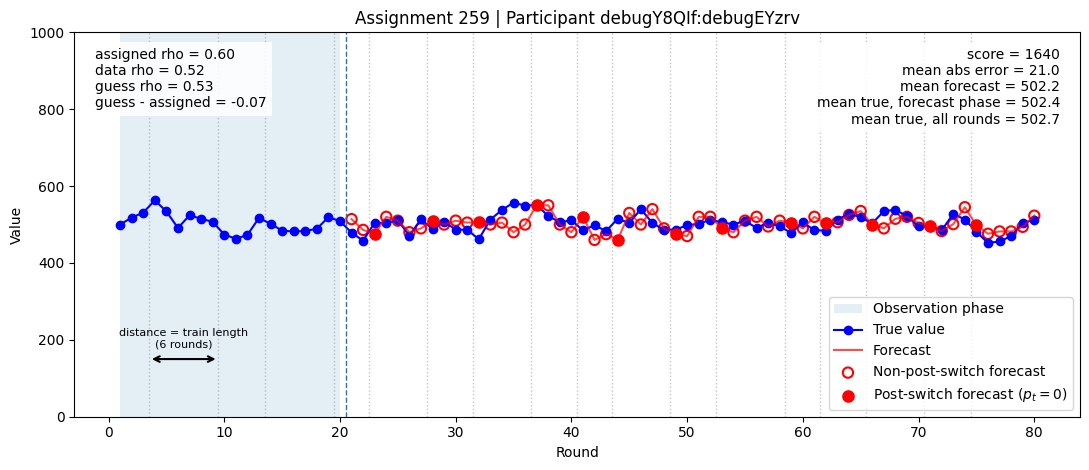

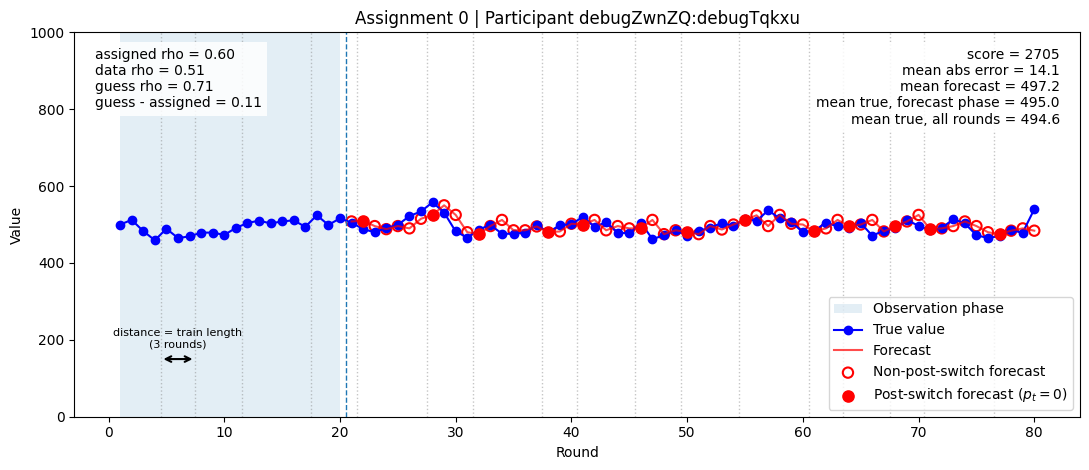

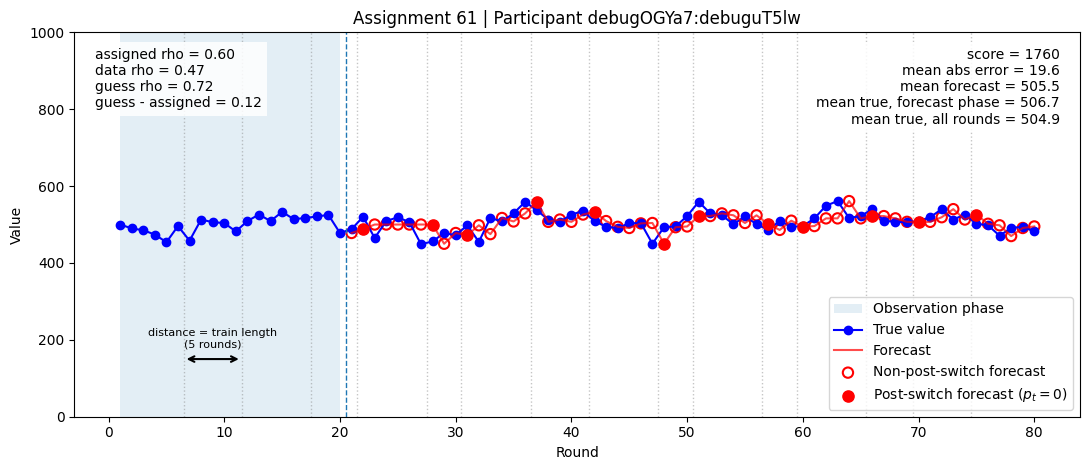

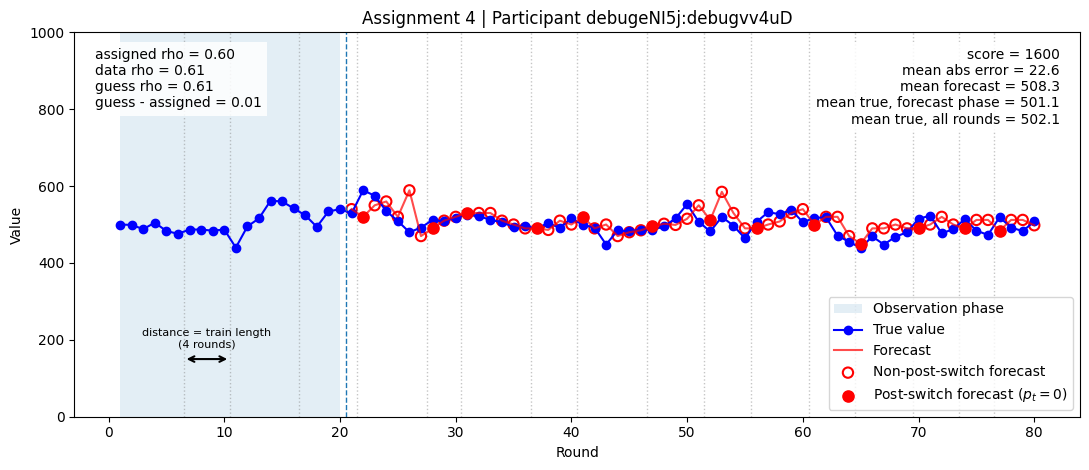

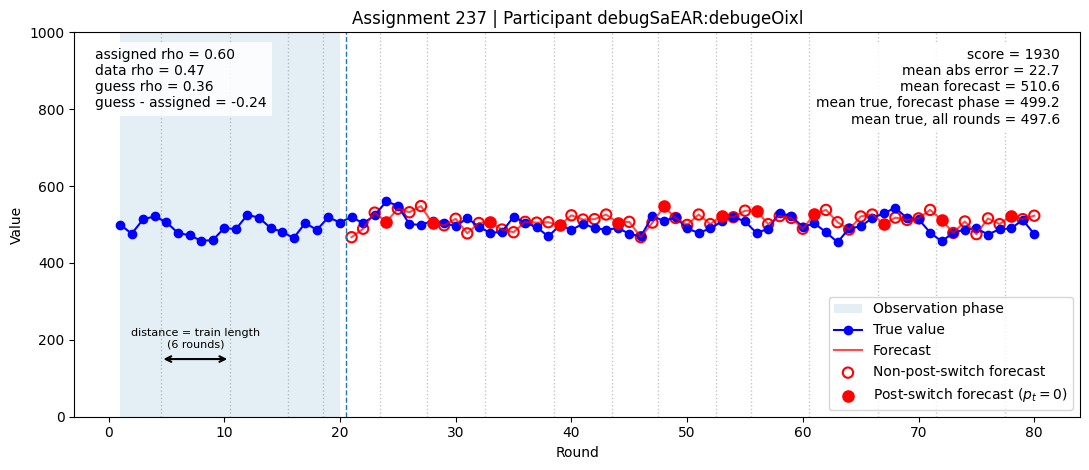

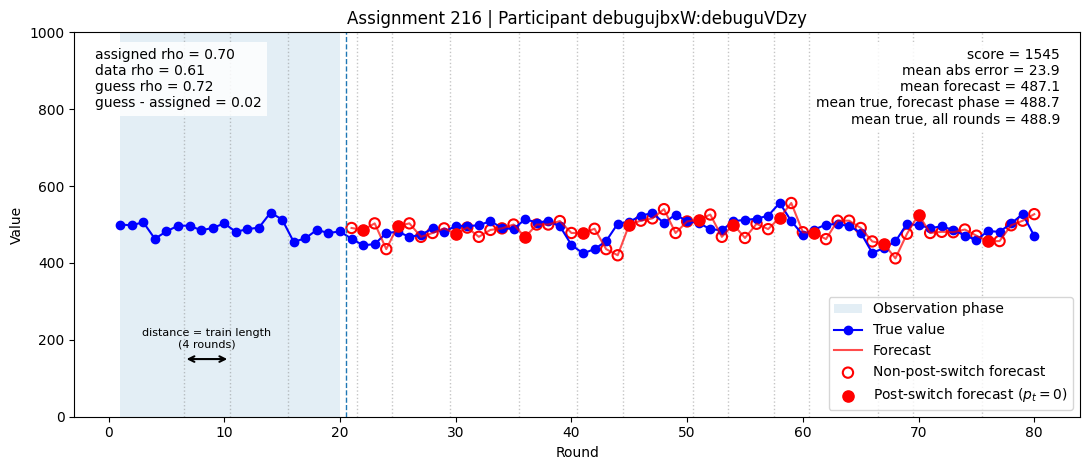

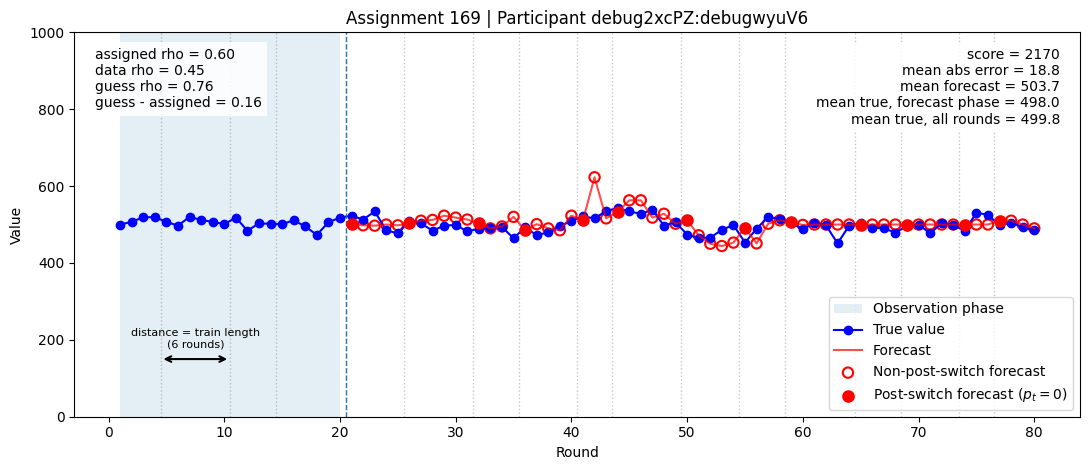

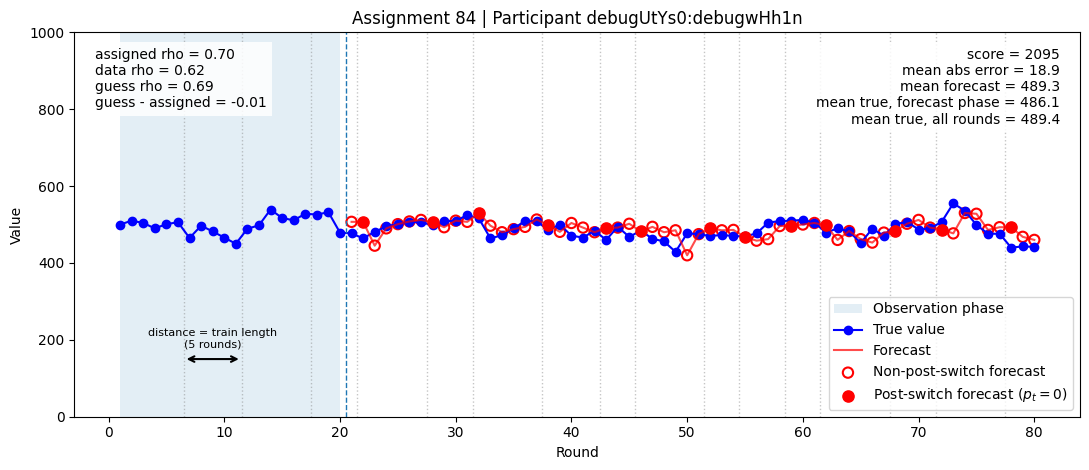

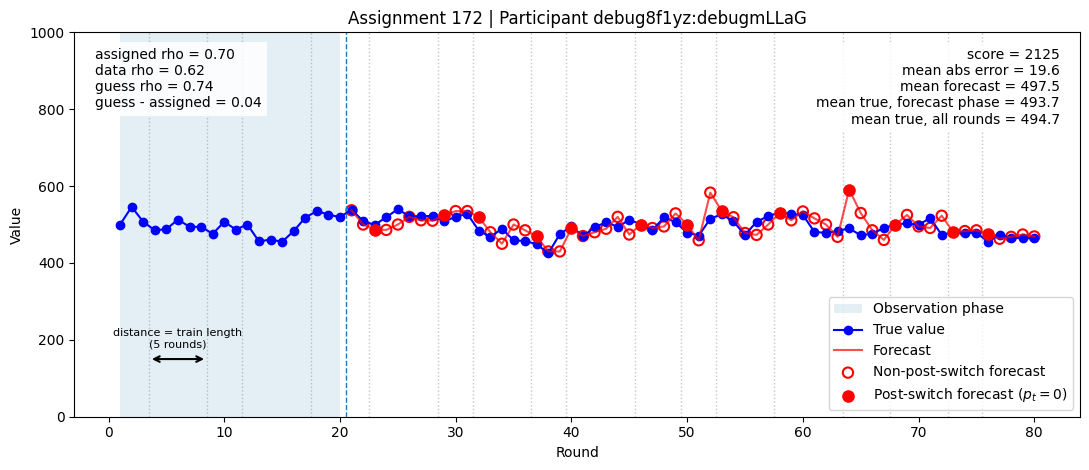

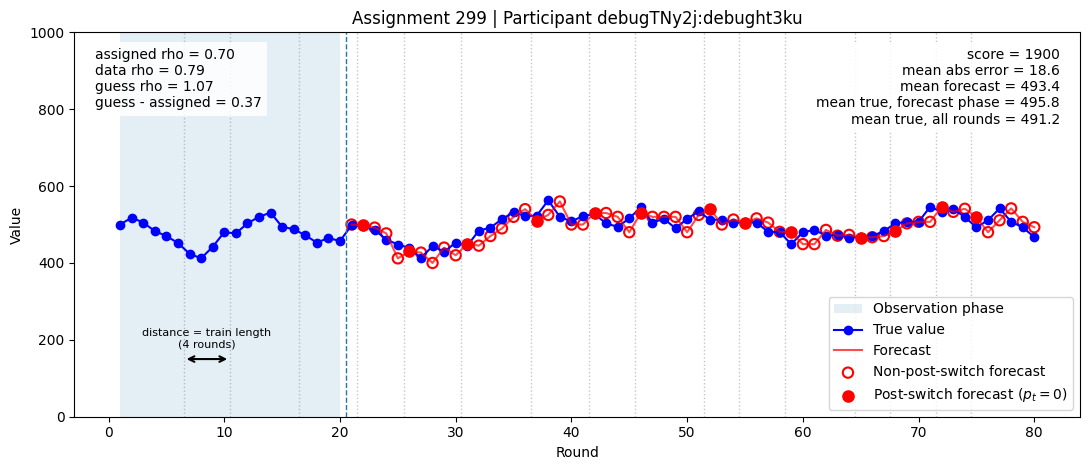

Saved recent participant plots to: /Users/oliversmirnov/Documents/GitHub/memory_forecasting/analysis_outputs/recent_participant_plots


In [ ]:
def add_third_train_distance_bracket(ax, g, y=930):
    """
    Add a bracket showing the distance between the first train and third train.

    Assumes:
      - g has display_round, train_id, task_type
      - train_id identifies contiguous task trains
      - the third train is the first return to the task type from train 1
    """

    train_summary = (
        g.dropna(subset=["train_id", "display_round"])
        .groupby("train_id", as_index=False)
        .agg(
            train_start=("display_round", "min"),
            train_end=("display_round", "max"),
            task_type=("task_type", "first"),
            train_length=("display_round", "count"),
        )
        .sort_values("train_start")
        .reset_index(drop=True)
    )

    if len(train_summary) < 3:
        return

    first_train = train_summary.iloc[0]
    second_train = train_summary.iloc[1]
    third_train = train_summary.iloc[2]

    # Optional safety check: third train should match first train's task type
    if third_train["task_type"] != first_train["task_type"]:
        return

    # Bracket spans the intervening train: after train 1, before train 3
    x_left = first_train["train_end"] + 0.5
    x_right = third_train["train_start"] - 0.5

    intervening_length = int(second_train["train_length"])

    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_right, y),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=1.5,
            color="black"
        )
    )

    ax.text(
        (x_left + x_right) / 2,
        y + 25,
        f"distance = train length\n({intervening_length} rounds)",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )

for participant_id in recent_participants:
    g = recent_plot_df[
        recent_plot_df[participant_col] == participant_id
    ].copy()

    if g.empty:
        continue

    g = g.sort_values("round_index").copy()

    # Display rounds as 1, 2, ..., 80 instead of 0, 1, ..., 79
    g["display_round"] = g["round_index"] + 1

    assigned_rho = g["assigned_rho"].dropna().iloc[0]
    assignment_slot = int(g["assignment_slot"].dropna().iloc[0])

    final_score = g["final_score"].dropna().max()
    if pd.isna(final_score):
        final_score_text = "NA"
    else:
        final_score_text = f"{final_score:.0f}"

    # Data/sample rho using the full true sequence, including observation phase
    data_rho = estimate_slope_from_centered_ols(
        g.dropna(subset=["x_t", "x_next_true"]),
        y_col="x_next_true",
        x_col="x_t"
    )

    # Guess/implied rho using only rows with forecasts
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    guess_rho = estimate_slope_from_centered_ols(
        forecast_rows_for_stats,
        y_col="forecast_value",
        x_col="x_t"
    )

    mean_abs_error = np.mean(
        np.abs(
            forecast_rows_for_stats["forecast_value"]
            - forecast_rows_for_stats["x_next_true"]
        )
    )

    mean_forecast = forecast_rows_for_stats["forecast_value"].mean()
    mean_true_forecast_phase = forecast_rows_for_stats["x_next_true"].mean()
    mean_true_all = g["x_next_true"].mean()

    stats_text_left = (
        f"assigned rho = {assigned_rho:.2f}\n"
        f"data rho = {data_rho:.2f}\n"
        f"guess rho = {guess_rho:.2f}\n"
        f"guess - assigned = {guess_rho - assigned_rho:.2f}"
    )

    stats_text_right = (
        f"score = {final_score_text}\n"
        f"mean abs error = {mean_abs_error:.1f}\n"
        f"mean forecast = {mean_forecast:.1f}\n"
        f"mean true, forecast phase = {mean_true_forecast_phase:.1f}\n"
        f"mean true, all rounds = {mean_true_all:.1f}"
    )

    fig, ax = plt.subplots(figsize=(11, 4.8))

    train_boundaries = (
        g[["display_round", "train_id"]]
        .dropna()
        .drop_duplicates()
        .sort_values("display_round")
        .copy()
    )

    train_boundaries["previous_train_id"] = train_boundaries["train_id"].shift(1)

    switch_rounds = train_boundaries.loc[
        train_boundaries["train_id"] != train_boundaries["previous_train_id"],
        "display_round"
    ]

    # Skip the first round, because it is the beginning of the task, not a switch
    switch_rounds = switch_rounds[switch_rounds > 1]

    for switch_round in switch_rounds:
        ax.axvline(
            switch_round - 0.5,
            linestyle=":",
            linewidth=1,
            color="grey",
            alpha=0.45
        )

    # Observation region
    ax.axvspan(
        1,
        FORECAST_START_INDEX,
        alpha=0.12,
        label="Observation phase"
    )

    # True values for all rounds, including observation
    ax.plot(
        g["display_round"],
        g["x_next_true"],
        marker="o",
        color="blue",
        label="True value"
    )

    # Forecast rows
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] == 0
    ].copy()

    non_post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] != 0
    ].copy()

    # Forecast line across all forecast rounds
    ax.plot(
        forecast_rows_for_stats["display_round"],
        forecast_rows_for_stats["forecast_value"],
        color="red",
        linewidth=1.5,
        alpha=0.70,
        label="Forecast"
    )

    # Non-post-switch forecasts: hollow red circles
    ax.scatter(
        non_post_switch_forecasts["display_round"],
        non_post_switch_forecasts["forecast_value"],
        facecolors="none",
        edgecolors="red",
        s=55,
        marker='o',
        linewidths=1.5,
        label="Non-post-switch forecast"
    )

    # Post-switch forecasts: filled red circles
    ax.scatter(
        post_switch_forecasts["display_round"],
        post_switch_forecasts["forecast_value"],
        color="red",
        s=65,
        marker='o',
        zorder=5,
        label=r"Post-switch forecast $(p_t=0)$"
    )
    
    add_third_train_distance_bracket(ax, g, y=150)

    # Mark transition into forecast phase
    ax.axvline(
        FORECAST_START_INDEX + 0.5,
        linestyle="--",
        linewidth=1
    )


    ax.set_ylim(0, 1000)
    ax.set_xlabel("Round")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Assignment {assignment_slot} | Participant {participant_id}"
    )

    ax.text(
        0.02,
        0.96,
        stats_text_left,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.text(
        0.98,
        0.96,
        stats_text_right,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.legend(loc="lower right")
    # ax.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = f"assignment_{assignment_slot}_{participant_id}.png"
    safe_filename = (
        filename
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )

    plt.savefig(OUT_DIR / safe_filename, dpi=150)
    plt.show()

print(f"Saved recent participant plots to: {OUT_DIR}")

In [ ]:
baseline_overreaction_table = persistence_tests.copy()

baseline_overreaction_table["stars"] = baseline_overreaction_table[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table["stars_vs_nominal"] = baseline_overreaction_table[
    "p_value_vs_nominal"
].apply(add_stars)

baseline_overreaction_table = baseline_overreaction_table[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(Markdown(
    "## 1. Baseline overreaction: implied persistence > realized persistence\n\n"
    "`mean_rho_excess` is implied persistence minus the persistence actually "
    "present in the series each participant saw (`mean_realized_rho`), not "
    "minus the nominal rho."
))

display(format_result_table(baseline_overreaction_table))

display(Markdown(
    "### Robustness: the same test benchmarked against the nominal rho"
))

display(format_result_table(
    persistence_tests[
        [
            "assigned_rho",
            "n_participants",
            "mean_rho_excess_vs_nominal",
            "t_stat_vs_nominal",
            "p_value_vs_nominal",
        ]
    ].assign(
        stars=persistence_tests["p_value_vs_nominal"].apply(add_stars)
    )
))

In [ ]:
postswitch_gamma_table = simple_gamma_postswitch_tests.copy()

postswitch_gamma_table["stars"] = postswitch_gamma_table[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table = postswitch_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(Markdown("## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1"))

display(format_result_table(postswitch_gamma_table))

## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",6,-0.1985,-0.1669,-2.5597,0.9747,
1,0.6,3,"[0, 1]",6,-0.2014,-0.1672,-2.5933,0.9757,
2,0.7,2,"[0, 1]",4,0.1337,0.1262,1.0808,0.1795,
3,0.7,3,"[0, 1]",4,0.1468,0.1282,1.2899,0.1438,


In [ ]:
interaction_gamma_table = interaction_gamma_tests.copy()

interaction_gamma_table["gamma_0_stars"] = interaction_gamma_table[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table["gamma_1_stars"] = interaction_gamma_table[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table = interaction_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(Markdown("## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0"))

display(format_result_table(interaction_gamma_table))

## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,6,-0.1910,-2.8781,0.9827,,0.0231,0.7546,0.7577,
1,0.6,3,6,-0.1989,-2.9743,0.9845,,0.0253,0.8775,0.7898,
2,0.7,2,4,0.1181,1.6745,0.0963,*,-0.0163,-0.9359,0.2092,
3,0.7,3,4,0.1193,1.8371,0.0818,*,-0.0150,-0.8376,0.2319,


In [ ]:
rho_comparison_table = gamma_condition_postswitch_tests.copy()

rho_comparison_table["stars"] = rho_comparison_table[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table = rho_comparison_table[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(Markdown("## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6"))

display(format_result_table(rho_comparison_table))

## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",6,4,-0.1985,0.1337,0.3322,2.2749,0.0344,**
1,3,"[0, 1]",6,4,-0.2014,0.1468,0.3482,2.5274,0.0234,**
